In [ ]:
!pip install -q torchgeo terratorch
import os
os.kill(os.getpid(), 9)   # terratorch swaps numpy under the running kernel, only a restart clears it

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.8/643.8 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.8/136.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
'''perception-gap, satellite-native baseline.

Every encoder in perception_gap.ipynb is a photo model pointed at satellite RGB. Prithvi
(NASA/IBM, arxiv/2310.18660) is the opposite: an MAE pretrained on satellite imagery that
eats six HLS bands (Blue, Green, Red, NIR, SWIR1, SWIR2). Same five perturbations, same SR,
same centered readout. Reported apart from the eleven RGB encoders because the input differs,
so the comparison bundles model with bands. That bundling is what a satellite FM is.

The readout is pinned to the final transformer block via a forward hook rather than taking
out[-1] from the wrapper. terratorch backbones return a configurable list of layers and that
default has changed between releases, so out[-1] is not a stable reference to any given depth.
Normalisation constants and the terratorch version are printed so the run is pinnable.

EuroSAT via torchgeo (arxiv/2111.08872). Prithvi via terratorch, github.com/IBM/terratorch.
'''
import os
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
from torchgeo.datasets import EuroSAT

SEED, N_TILES, N_BOOT = 42, 300, 2000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)

BANDS = ("B02", "B03", "B04", "B08", "B11", "B12")   # Sentinel-2 ids in Prithvi's order
ds = EuroSAT(root="data/eurosat_ms", split="train", bands=BANDS, download=True)

def load_tile(i):
    img = ds[int(i)]["image"].float()                 # (6, 64, 64) reflectance
    assert img.shape[0] == 6, f"expected 6 bands, got {img.shape[0]}"
    return F.interpolate(img[None], size=224, mode="bilinear", align_corners=False)[0]

tiles = [load_tile(i) for i in np.random.choice(len(ds), N_TILES, replace=False)]


def occlude_center(img, frac=0.4):
    out = img.clone()
    h, w = img.shape[1:]
    a, b = int(h * (1 - frac) / 2), int(w * (1 - frac) / 2)
    out[:, a:h - a, b:w - b] = img.mean((1, 2), keepdim=True)
    return out

def scramble_patches(img, grid=4):
    h, w = img.shape[1:]
    ph, pw = h // grid, w // grid
    patches = [img[:, i * ph:(i + 1) * ph, j * pw:(j + 1) * pw]
               for i in range(grid) for j in range(grid)]
    out = torch.empty_like(img)
    for k, src in enumerate(np.random.permutation(len(patches))):
        i, j = divmod(k, grid)
        out[:, i * ph:(i + 1) * ph, j * pw:(j + 1) * pw] = patches[src]
    return out

def rotate_90(img):
    return torch.rot90(img, 1, (1, 2))

def flip_vertical(img):
    return torch.flip(img, (1,))

OCC_L2 = (tiles[0] - occlude_center(tiles[0])).norm().item()

def matched_noise(img):
    n = torch.randn_like(img)
    return (img + n * (OCC_L2 / n.norm())).clamp_min(0.0)  # reflectance cannot go negative

PERTURBATIONS = {
    "occlude_center":   ("meaningful", occlude_center),
    "scramble_patches": ("meaningful", scramble_patches),
    "rotate_90":        ("cosmetic", rotate_90),
    "flip_vertical":    ("cosmetic", flip_vertical),
    "matched_noise":    ("cosmetic", matched_noise),
}

torch.manual_seed(SEED); np.random.seed(SEED)
PERTURBED = {k: [fn(t) for t in tiles] for k, (_, fn) in PERTURBATIONS.items()}


def cosine_shifts(base, pert, center=True):
    mu = base.mean(0, keepdims=True) if center else 0.0
    b = base - mu
    bn = np.linalg.norm(b, axis=1)
    return {k: 1.0 - (b * (p - mu)).sum(1) / (bn * np.linalg.norm(p - mu, axis=1) + 1e-12)
            for k, p in pert.items()}

def sr(shifts, idx=None):
    def g(kind):
        return float(np.mean([(s if idx is None else s[idx]).mean()
                              for k, s in shifts.items() if PERTURBATIONS[k][0] == kind]))
    sig, cos = g("meaningful"), g("cosmetic")
    return sig, cos, sig / (sig + cos)

def bootstrap_ci(shifts, n=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    N = len(next(iter(shifts.values())))
    return np.percentile([sr(shifts, rng.integers(0, N, N))[2] for _ in range(n)], [2.5, 97.5])


from importlib.metadata import version as pkg_version
TT = pkg_version("terratorch")
from terratorch import BACKBONE_REGISTRY
from terratorch.models.backbones.prithvi_vit import PRITHVI_V1_MEAN, PRITHVI_V1_STD

model = BACKBONE_REGISTRY.build("prithvi_eo_v1_100", pretrained=True).eval().to(DEVICE)
MEAN = torch.tensor(PRITHVI_V1_MEAN, device=DEVICE).view(-1, 1, 1)
STD = torch.tensor(PRITHVI_V1_STD, device=DEVICE).view(-1, 1, 1)

# find the transformer blocks wherever this build keeps them, then hook the last one
blocks = None
for path in ("blocks", "encoder.blocks", "model.blocks", "encoder.encoder.blocks"):
    obj = model
    for part in path.split("."):
        obj = getattr(obj, part, None)
        if obj is None:
            break
    if isinstance(obj, torch.nn.ModuleList) and len(obj):
        blocks, found = obj, path
        break
assert blocks is not None, f"no block list found; top-level children: {[n for n, _ in model.named_children()]}"

tap = {}
blocks[-1].register_forward_hook(lambda m, inp, out: tap.__setitem__("h", out))

# the encoder wants (B,C,T,H,W) with T=1 per the docs, but some builds take (B,C,H,W)
probe, USE_5D, err = torch.zeros(1, 6, 224, 224, device=DEVICE), None, None
with torch.no_grad():
    for cand in (True, False):
        try:
            model(probe[:, :, None] if cand else probe)
            USE_5D = cand
            break
        except Exception as e:
            err = e
assert USE_5D is not None, f"prithvi forward failed for both 5D and 4D input: {err}"
assert "h" in tap, "hook never fired, the block list is not on the forward path"
assert tap["h"].ndim == 3, f"expected (B, tokens, dim) from the last block, got {tuple(tap['h'].shape)}"

print(f"terratorch {TT}   blocks at model.{found}, {len(blocks)} deep")
print(f"last-block output {tuple(tap['h'].shape)}")
print(f"PRITHVI_V1_MEAN {[round(float(x), 4) for x in PRITHVI_V1_MEAN]}")
print(f"PRITHVI_V1_STD  {[round(float(x), 4) for x in PRITHVI_V1_STD]}\n")

def featurize(img):
    x = ((img.to(DEVICE) - MEAN) / STD)[None]
    if USE_5D:
        x = x[:, :, None]
    with torch.no_grad():
        model(x)
    return tap["h"][0].mean(0).float().cpu().numpy()   # mean over tokens, as the other ViTs


base = np.stack([featurize(t) for t in tiles])
pert = {k: np.stack([featurize(p) for p in imgs]) for k, imgs in PERTURBED.items()}
shifts = cosine_shifts(base, pert)
sig, cos, ratio = sr(shifts)
lo, hi = bootstrap_ci(shifts)

for k, (kind, _) in PERTURBATIONS.items():
    print(f"  {k:<17} {kind:<11} {shifts[k].mean():.4f}")
print(f"\nPrithvi-EO-1.0-100M   SR {ratio:.3f}  [{lo:.3f} {hi:.3f}]   "
      f"signal {sig:.3f}  cosmetic {cos:.3f}")

# the noise perturbation drives most of the cosmetic response, so check it is fair in
# reflectance units rather than pathologically harsh
t = tiles[0]
torch.manual_seed(0)
n = torch.randn_like(t)
n = n * (OCC_L2 / n.norm())
print(f"noise check: {100 * float(n.std()) / float(t.std()):.0f}% of the tile's spatial std, "
      f"{float(((t + n) < 0).float().mean()):.3f} of pixels clamped at zero")

os.makedirs("results", exist_ok=True)
pd.DataFrame([dict(model="Prithvi-EO-1.0-100M", objective="reconstruction (satellite-native)",
                   data="HLS 6-band", terratorch=TT, signal=sig,
                   cosmetic=cos, sr=ratio, ci_low=lo, ci_high=hi, inert=sig < 0.02)]).to_csv(
    "results/prithvi_sr.csv", index=False)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Prithvi_EO_V1_100M.pt: reconstructing file:   0%|          |  0.00B /  454MB            

Prithvi_EO_V1_100M.pt: downloading bytes:           |  0.00B            

terratorch 1.2.10   blocks at model.blocks, 12 deep
last-block output (1, 197, 768)
PRITHVI_V1_MEAN [775.0, 1081.0, 1229.0, 2497.0, 2204.0, 1611.0]
PRITHVI_V1_STD  [1282.0, 1270.0, 1399.0, 1368.0, 1292.0, 1155.0]

  occlude_center    meaningful  0.0145
  scramble_patches  meaningful  0.0910
  rotate_90         cosmetic    0.0110
  flip_vertical     cosmetic    0.0082
  matched_noise     cosmetic    0.4251

Prithvi-EO-1.0-100M   SR 0.263  [0.235 0.291]   signal 0.053  cosmetic 0.148
noise check: 25% of the tile's spatial std, 0.000 of pixels clamped at zero


In [ ]:
'''The eleven RGB encoders on the SAME tiles Prithvi just saw, so all twelve models are
measured on identical scenes under identical perturbations. Perturbation happens in
6-band space first, then RGB is extracted, so every model sees the same physical change.

Reflectance runs in the thousands, which ImageNet encoders have never seen, so RGB is
stretched by a single global divisor computed once from the unperturbed tiles. It has to
be global: a per-image stretch would let the occlusion change its own normalisation.

These SRs are NOT comparable to perception_gap.ipynb. Different tile sample, different
RGB rendering. They are only comparable to the Prithvi number above.

Runs after the Prithvi cell in the same session, reusing tiles, PERTURBED, cosine_shifts,
sr and bootstrap_ci. Prithvi still sees six bands, the eleven see three, and that gap is
intrinsic to what a satellite foundation model is rather than a confound to remove.
'''
import gc

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
IMNET_STD = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
RGB_IDX = [2, 1, 0]                                  # B04, B03, B02 out of the Prithvi order
SCALE = float(np.quantile(torch.stack([t[RGB_IDX] for t in tiles]).numpy(), 0.98))

def to_rgb(img):
    x = (img[RGB_IDX] / SCALE).clamp(0, 1)
    return (x - IMNET_MEAN) / IMNET_STD

RGB_BASE = [to_rgb(t) for t in tiles]
RGB_PERTURBED = {k: [to_rgb(p) for p in imgs] for k, imgs in PERTURBED.items()}
print(f"stretch divisor {SCALE:.0f} reflectance, tile rgb after imagenet norm: "
      f"mean {float(torch.stack(RGB_BASE).mean()):.2f} std {float(torch.stack(RGB_BASE).std()):.2f}")


def rgb_features(featurize):
    base = np.stack([featurize(t) for t in RGB_BASE])
    return base, {k: np.stack([featurize(p) for p in imgs]) for k, imgs in RGB_PERTURBED.items()}


def dinov2(size):
    m = torch.hub.load("facebookresearch/dinov2", f"dinov2_vit{size}14", pretrained=True)
    m = m.eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            h = m.forward_features(img[None].to(DEVICE))["x_norm_patchtokens"]
        return h[0].mean(0).float().cpu().numpy()
    return f

def dino1():
    m = torch.hub.load("facebookresearch/dino:main", "dino_vitb16", pretrained=True)
    m = m.eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def torchvision_vit():
    from torchvision.models import vit_b_32, ViT_B_32_Weights
    m = vit_b_32(weights=ViT_B_32_Weights.IMAGENET1K_V1).eval().to(DEVICE)
    m.heads = torch.nn.Identity()
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def resnet50():
    from torchvision.models import resnet50 as build, ResNet50_Weights
    m = build(weights=ResNet50_Weights.IMAGENET1K_V2).eval().to(DEVICE)
    m.fc = torch.nn.Identity()
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def timm_model(name):
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0).eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def ijepa(repo):
    from transformers import AutoModel
    m = AutoModel.from_pretrained(repo, dtype=torch.float16).eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            h = m(pixel_values=img[None].to(DEVICE).half()).last_hidden_state
        return h[0].mean(0).float().cpu().numpy()
    return f

def pixtral():
    import json, safetensors.torch
    from huggingface_hub import hf_hub_download
    from transformers import AutoConfig, PixtralVisionModel
    repo = "mistral-community/pixtral-12b"
    m = PixtralVisionModel(AutoConfig.from_pretrained(repo).vision_config)
    wmap = json.load(open(hf_hub_download(repo, "model.safetensors.index.json")))["weight_map"]
    prefix = next(k for k in wmap if k.endswith("patch_conv.weight"))[:-len("patch_conv.weight")]
    state = {}
    for shard in sorted({s for k, s in wmap.items() if k.startswith(prefix)}):
        sd = safetensors.torch.load_file(hf_hub_download(repo, shard))
        state.update({k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)})
    missing, _ = m.load_state_dict(state, strict=False)
    assert not missing, f"pixtral vision weights missing: {missing[:5]}"
    m = m.eval().to(DEVICE).half()
    def f(img):
        x = img[None].to(DEVICE).half()
        with torch.no_grad():
            out = m(pixel_values=x, image_sizes=torch.tensor([x.shape[-2:]], device=DEVICE))
        h = getattr(out, "last_hidden_state", None)
        return (out[0] if h is None else h)[0].mean(0).float().cpu().numpy()
    return f


MODELS = [
    ("DINOv2 ViT-S/14",       "self-distillation", lambda: dinov2("s")),
    ("DINOv2 ViT-B/14",       "self-distillation", lambda: dinov2("b")),
    ("DINOv1 ViT-B/16",       "self-distillation", dino1),
    ("ViT-B/32",              "supervised",        torchvision_vit),
    ("ResNet-50",             "supervised",        resnet50),
    ("ConvNeXt-Tiny",         "supervised",        lambda: timm_model("convnext_tiny.fb_in22k")),
    ("EfficientNet-B0",       "supervised",        lambda: timm_model("efficientnet_b0.ra_in1k")),
    ("MAE ViT-B/16",          "reconstruction",    lambda: timm_model("vit_base_patch16_224.mae")),
    ("I-JEPA ViT-H/14",       "joint-embedding",   lambda: ijepa("facebook/ijepa_vith14_1k")),
    ("I-JEPA ViT-H/14 (22k)", "joint-embedding",   lambda: ijepa("facebook/ijepa_vith14_22k")),
    ("Pixtral-ViT",           "language",          pixtral),
]

rows = []
for name, objective, load in MODELS:
    f = None
    try:
        f = load()
        base, pert = rgb_features(f)
    except Exception as e:
        print(f"{name:<22} failed: {type(e).__name__}: {e}")
        continue
    finally:
        f = None
        gc.collect(); torch.cuda.empty_cache()

    s = cosine_shifts(base, pert)
    sig, cos, ratio = sr(s)
    geom = float(np.mean([s[k].mean() for k in ("rotate_90", "flip_vertical")]))
    lo, hi = bootstrap_ci(s)
    print(f"{name:<22} {ratio:.3f}  [{lo:.3f} {hi:.3f}]   signal {sig:.3f}  "
          f"cosmetic {cos:.3f}   geometry-only SR {sig / (sig + geom):.3f}")
    rows.append(dict(model=name, objective=objective, signal=sig, cosmetic=cos, sr=ratio,
                     ci_low=lo, ci_high=hi, sr_geometry_only=sig / (sig + geom),
                     noise_shift=float(s["matched_noise"].mean())))

shared = pd.DataFrame(rows).sort_values("sr", ascending=False)
print()
print(shared.to_string(index=False))
shared.to_csv("results/same_tiles_rgb.csv", index=False)

stretch divisor 2223 reflectance, tile rgb after imagenet norm: mean 0.08 std 0.88
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 192MB/s]


DINOv2 ViT-S/14        0.428  [0.415 0.441]   signal 0.226  cosmetic 0.302   geometry-only SR 0.538


...

config.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.9k [00:00<?, ?B/s]

model-00001-of-00006.safetensors: reconstructing file:   0%|          |  0.00B / 4.99GB            

model-00001-of-00006.safetensors: downloading bytes:           |  0.00B            

Pixtral-ViT            0.474  [0.462 0.486]   signal 0.362  cosmetic 0.402   geometry-only SR 0.543

                model         objective   signal  cosmetic       sr   ci_low  ci_high  sr_geometry_only  noise_shift
             ViT-B/32        supervised 0.315404  0.309370 0.504829 0.494859 0.514212          0.587157     0.484575
        ConvNeXt-Tiny        supervised 0.345681  0.345130 0.500398 0.493165 0.507481          0.586444     0.547847
I-JEPA ViT-H/14 (22k)   joint-embedding 0.403806  0.411520 0.495269 0.484398 0.505481          0.697553     0.884394
      DINOv1 ViT-B/16 self-distillation 0.310778  0.321004 0.491907 0.482365 0.501740          0.622596     0.586240
          Pixtral-ViT          language 0.362342  0.402208 0.473929 0.462035 0.486271          0.542500     0.595486
      I-JEPA ViT-H/14   joint-embedding 0.295233  0.372240 0.442315 0.430230 0.453822          0.597190     0.718444
      DINOv2 ViT-B/14 self-distillation 0.237691  0.307653 0.435855 0.422665 0.4

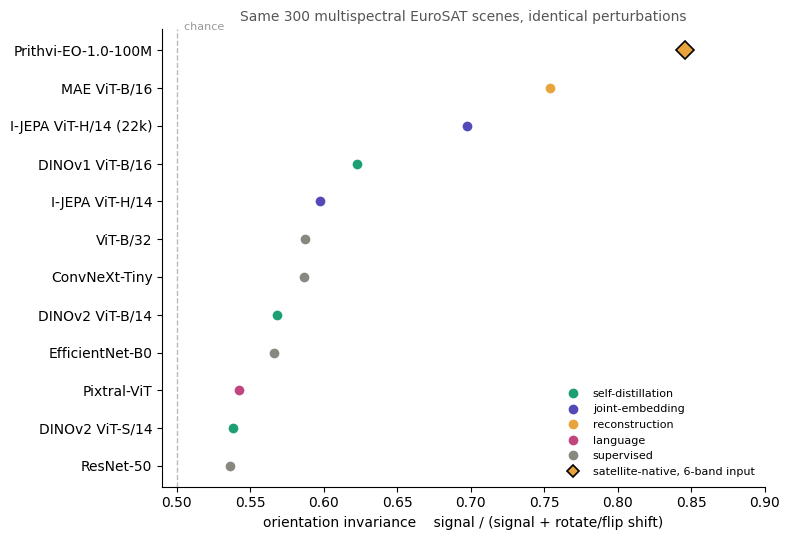

In [ ]:
'''Orientation invariance across all twelve, on identical scenes. Rotation and vertical flip
are exact pixel operations, so unlike matched_noise there is no magnitude to match and no
scaling choice: every model got the same operation on the same tile. That makes this the
one fully fair cross-model axis in the notebook, which is why it gets the figure and the
noise-inclusive SR does not.

No error bars: the geometry-only bootstrap was never computed, and the intervals in the
csv belong to the noise-inclusive SR, a different quantity. Read the spread, not the
fine rank ordering.

Runs after the same_tiles cell in the same session. Prithvi's per-tile shifts are still
bound to `shifts` from the Prithvi cell, which same_tiles did not overwrite.
'''
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COLORS = {"self-distillation": "#1D9E75", "joint-embedding": "#534AB7",
          "reconstruction": "#E8A33D", "language": "#C1467F", "supervised": "#888780"}

p_sig = sr(shifts)[0]
p_geom = float(np.mean([shifts[k].mean() for k in ("rotate_90", "flip_vertical")]))
df = pd.read_csv("results/same_tiles_rgb.csv")[["model", "objective", "sr_geometry_only"]]
df = pd.concat([df, pd.DataFrame([dict(model="Prithvi-EO-1.0-100M", objective="reconstruction",
                                       sr_geometry_only=p_sig / (p_sig + p_geom))])])
df = df.sort_values("sr_geometry_only").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
for y, r in enumerate(df.itertuples()):
    native = r.model.startswith("Prithvi")
    ax.plot(r.sr_geometry_only, y, marker="D" if native else "o",
            ms=9 if native else 7, color=COLORS[r.objective],
            mec="black" if native else "none", mew=1.2, zorder=3)
ax.axvline(0.5, ls="--", lw=1, color="#bbb", zorder=1)
ax.text(0.5, len(df) - 0.4, "  chance", color="#999", fontsize=8, va="center")
ax.set_yticks(range(len(df)), df.model)
ax.set_xlim(0.49, 0.90)
ax.set_xlabel("orientation invariance    signal / (signal + rotate/flip shift)")
ax.set_title("Same 300 multispectral EuroSAT scenes, identical perturbations", fontsize=10, color="#555")
handles = [Line2D([], [], marker="o", ls="", color=c, label=k)
           for k, c in COLORS.items() if k in set(df.objective)]
handles.append(Line2D([], [], marker="D", ls="", color="#E8A33D", mec="black", mew=1.2,
                      label="satellite-native, 6-band input"))
ax.legend(handles=handles, fontsize=8, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/orientation_invariance.png", dpi=150, bbox_inches="tight")
plt.show()